In [120]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import zscore


# Outlier Detection

## Method 1 : Interquartile Range

1. Uses middle 50% of data

2. Anything outside normal range = outlier

3. Robust to skewed data

In [121]:
# Sample data
data = np.array([
    48, 50, 52, 49, 51, 47, 53, 50, 49, 52,
    48, 51, 50, 49, 52, 47, 53, 50, 51, 49,
    120, 130
])

# Step 1: Calculate Q1, Q3 to detect outliers
Q1 = np.percentile(data, 25)
Q3 = np.percentile(data, 75)

# Step 2: Calculate Inter Quartile Range
IQR = Q3 - Q1

# Step 3: Defining the bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Step 4: Detect outliers
outliers = data[(data < lower_bound) | (data > upper_bound)]

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Outliers detected:", outliers)

Lower Bound: 44.5
Upper Bound: 56.5
Outliers detected: [120 130]


## Method 2: Z-score method

1. Measures distance from mean

2. Assumes data is normally distributed

3. Sensitive to extreme values

In [122]:
import numpy as np

# Sample data
data = np.array([
    48, 50, 52, 49, 51, 47, 53, 50, 49, 52,
    48, 51, 50, 49, 52, 47, 53, 50, 51, 49,
    120, 130
])

# Calculate Z-scores
z_scores = zscore(data)

# Detect outliers (|z| > 2)
outliers = data[np.abs(z_scores) > 2]

print("Outliers detected:", outliers)


Outliers detected: [120 130]


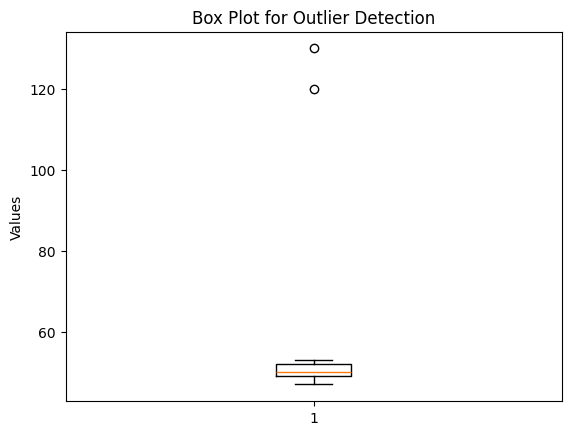

Outliers detected using box plot: [120 130]


In [123]:
plt.figure()
box = plt.boxplot(data)
plt.title("Box Plot for Outlier Detection")
plt.ylabel("Values")
plt.show()

outliers = box["fliers"][0].get_ydata()
print("Outliers detected using box plot:", outliers)

# Handling missing values

In [124]:
data = [
    {"id": 101, "name": "Rahul",   "age": 25,  "salary": 45000.50, "city": "Delhi",     "join_date": "2023-06-01"},
    {"id": 102, "name": "Anita",   "age": None,"salary": 52000.00, "city": "Mumbai",    "join_date": "2023-06-03"},
    {"id": 103, "name": "Suresh",  "age": 29,  "salary": None,     "city": "Bangalore", "join_date": "2023-06-05"},
    {"id": 104, "name": "Meena",   "age": 35,  "salary": 68000.75, "city": None,        "join_date": "2023-06-07"},
    {"id": 105, "name": "Ravi",    "age": 28,  "salary": 48000.00, "city": "Chennai",   "join_date": None},
    {"id": 102, "name": "Anita",   "age": None,"salary": 52000.00, "city": "Mumbai",    "join_date": "2023-06-03"},
    {"id": 106, "name": "Kavya",   "age": 26,  "salary": 47000.25, "city": "Delhi",     "join_date": "2023-06-10"},
    {"id": 107, "name": "Rahul",   "age": 25,  "salary": 45000.50, "city": "Delhi",     "join_date": "2023-06-01"}
]

df = pd.DataFrame(data)


In [125]:
df.head()

,id,name,age,salary,city,join_date
0,101,Rahul,25.0,45000.50,Delhi,2023-06-01
1,102,Anita,NaN,52000.00,Mumbai,2023-06-03
2,103,Suresh,29.0,NaN,Bangalore,2023-06-05
3,104,Meena,35.0,68000.75,None,2023-06-07
4,105,Ravi,28.0,48000.00,Chennai,None


In [126]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         8 non-null      int64  
 1   name       8 non-null      object 
 2   age        6 non-null      float64
 3   salary     7 non-null      float64
 4   city       7 non-null      object 
 5   join_date  7 non-null      object 
dtypes: float64(2), int64(1), object(3)
memory usage: 512.0+ bytes


In [127]:
df.describe()

,id,age,salary
count,8.00000,6.000000,7.000000
mean,103.75000,28.000000,51000.285714
std,2.12132,3.794733,8041.677899
min,101.00000,25.000000,45000.500000
25%,102.00000,25.250000,46000.375000
50%,103.50000,27.000000,48000.000000
75%,105.25000,28.750000,52000.000000
max,107.00000,35.000000,68000.750000


In [128]:
df = df.drop_duplicates()

In [129]:
df

,id,name,age,salary,city,join_date
0,101,Rahul,25.0,45000.50,Delhi,2023-06-01
1,102,Anita,NaN,52000.00,Mumbai,2023-06-03
2,103,Suresh,29.0,NaN,Bangalore,2023-06-05
3,104,Meena,35.0,68000.75,None,2023-06-07
4,105,Ravi,28.0,48000.00,Chennai,None
6,106,Kavya,26.0,47000.25,Delhi,2023-06-10
7,107,Rahul,25.0,45000.50,Delhi,2023-06-01


In [130]:
df["age"] = pd.to_numeric(df["age"], errors="coerce")
df["join_date"] = pd.to_datetime(df["join_date"], errors="coerce")

In [131]:
df["city"] = df["city"].str.lower().str.strip()

In [132]:
df.isnull().sum()

id           0
name         0
age          1
salary       1
city         1
join_date    1
dtype: int64

In [133]:
df.dropna()                 # drop rows
df.dropna(axis=1)           # drop columns

,id,name
0,101,Rahul
1,102,Anita
2,103,Suresh
3,104,Meena
4,105,Ravi
6,106,Kavya
7,107,Rahul


In [134]:
df

,id,name,age,salary,city,join_date
0,101,Rahul,25.0,45000.50,delhi,2023-06-01
1,102,Anita,NaN,52000.00,mumbai,2023-06-03
2,103,Suresh,29.0,NaN,bangalore,2023-06-05
3,104,Meena,35.0,68000.75,None,2023-06-07
4,105,Ravi,28.0,48000.00,chennai,NaT
6,106,Kavya,26.0,47000.25,delhi,2023-06-10
7,107,Rahul,25.0,45000.50,delhi,2023-06-01


In [135]:
df['age'] = df["age"].fillna(df["age"].mean())

In [136]:
df['salary'] = df["salary"].fillna(df["salary"].median())

In [137]:
df['city'] = df["city"].fillna(df["city"].mode()[0])

In [138]:
today_timestamp = pd.Timestamp.today()
today_date = today_timestamp.date()

df['join_date'] = df["join_date"].fillna(today_date)

In [139]:
df

,id,name,age,salary,city,join_date
0,101,Rahul,25.0,45000.500,delhi,2023-06-01 00:00:00
1,102,Anita,28.0,52000.000,mumbai,2023-06-03 00:00:00
2,103,Suresh,29.0,47500.125,bangalore,2023-06-05 00:00:00
3,104,Meena,35.0,68000.750,delhi,2023-06-07 00:00:00
4,105,Ravi,28.0,48000.000,chennai,2026-01-29
6,106,Kavya,26.0,47000.250,delhi,2023-06-10 00:00:00
7,107,Rahul,25.0,45000.500,delhi,2023-06-01 00:00:00


In [140]:
df["join_date"] = pd.to_datetime(df["join_date"], errors="coerce")
df["join_date"] = df["join_date"].fillna(pd.Timestamp.today())

In [141]:
df

,id,name,age,salary,city,join_date
0,101,Rahul,25.0,45000.500,delhi,2023-06-01
1,102,Anita,28.0,52000.000,mumbai,2023-06-03
2,103,Suresh,29.0,47500.125,bangalore,2023-06-05
3,104,Meena,35.0,68000.750,delhi,2023-06-07
4,105,Ravi,28.0,48000.000,chennai,2026-01-29
6,106,Kavya,26.0,47000.250,delhi,2023-06-10
7,107,Rahul,25.0,45000.500,delhi,2023-06-01
